# Prompt Chaining Pattern

**Pattern**: Sequential LLM calls where output of one feeds into the next.

**Workflow**:
```
[Topic] → [Generate Text] → [Generate Summary] → [Output]
```

In this example:
1. User provides a topic
2. First LLM call generates detailed text about the topic
3. Second LLM call summarizes that text

## Setup

In [4]:
import os
from typing import TypedDict

from langgraph.graph import StateGraph, START, END


## Define State

State holds all data flowing through the graph:
- `topic`: Input from user
- `generated_text`: Output from first LLM call
- `summary`: Output from second LLM call

In [5]:
class State(TypedDict):
    topic: str
    generated_text: str
    summary: str

## Initialize LLM

In [6]:
from langchain.chat_models import init_chat_model


llm = init_chat_model(
    "us.anthropic.claude-sonnet-4-6",
    model_provider="bedrock_converse",
)

## Define Nodes

Each node is a function that:
- Receives current state
- Performs its task
- Returns state updates (only the fields it changes)

In [7]:
def generate_text(state: State) -> dict:
    """Node 1: Generate detailed text about the topic."""
    topic = state["topic"]
    
    prompt = f"""Write a detailed, informative paragraph (150-200 words) about the following topic:

Topic: {topic}

Include key facts, concepts, and interesting details."""
    
    response = llm.invoke(prompt)
    
    return {"generated_text": response.content}

In [8]:
def generate_summary(state: State) -> dict:
    """Node 2: Summarize the generated text."""
    text = state["generated_text"]
    
    prompt = f"""Summarize the following text in 2-3 concise sentences:

Text: {text}

Summary:"""
    
    response = llm.invoke(prompt)
    
    return {"summary": response.content}

## Build the Graph

```
START → generate_text → generate_summary → END
```

In [9]:
# Create the graph
graph = StateGraph(State)

# Add nodes
graph.add_node("generate_text", generate_text)
graph.add_node("generate_summary", generate_summary)

# Add edges (define the flow)
graph.add_edge(START, "generate_text")
graph.add_edge("generate_text", "generate_summary")
graph.add_edge("generate_summary", END)

# Compile the graph
app = graph.compile()

## Visualize the Graph

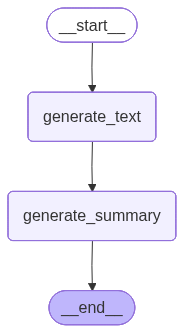

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## Run the Workflow

In [11]:
# Execute with a topic
result = app.invoke({"topic": "Quantum Computing"})

print("=" * 50)
print("TOPIC:", result["topic"])
print("=" * 50)
print("\nGENERATED TEXT:")
print(result["generated_text"])
print("\n" + "=" * 50)
print("\nSUMMARY:")
print(result["summary"])

TOPIC: Quantum Computing

GENERATED TEXT:
## Quantum Computing: A Revolutionary Paradigm

Quantum computing represents a fundamentally different approach to information processing, harnessing the principles of quantum mechanics to perform calculations that would be practically impossible for classical computers. Unlike traditional computers that process information using binary bits (0s and 1s), quantum computers utilize **qubits**, which can exist in multiple states simultaneously through a phenomenon called **superposition**. Additionally, qubits can become **entangled**, meaning the state of one qubit instantly influences another, regardless of physical distance. This allows quantum computers to evaluate enormous numbers of possibilities simultaneously rather than sequentially. Another key principle, **quantum interference**, helps amplify correct solutions while canceling incorrect ones. Companies like IBM, Google, and startups like IonQ are racing to achieve **quantum advantage** 

## Stream Execution (See Each Step)

In [12]:
# Stream to see state updates at each node
for step in app.stream({"topic": "Machine Learning"}):
    print("\n--- Step ---")
    for node_name, output in step.items():
        print(f"Node: {node_name}")
        for key, value in output.items():
            print(f"  {key}: {value[:100]}..." if len(str(value)) > 100 else f"  {key}: {value}")


--- Step ---
Node: generate_text
  generated_text: ## Machine Learning: An Overview

Machine learning (ML) is a transformative subset of artificial int...

--- Step ---
Node: generate_summary
  summary: Machine learning (ML) is a branch of artificial intelligence that enables systems to learn from data...


## Try Your Own Topic

In [ ]:
# Change the topic and run!
my_topic = "Climate Change"  # <-- Change this

result = app.invoke({"topic": my_topic})

print(f"Topic: {result['topic']}\n")
print(f"Text:\n{result['generated_text']}\n")
print(f"Summary:\n{result['summary']}")

## Key Takeaways

1. **Prompt Chaining** breaks complex tasks into sequential steps
2. Each **node** is an isolated function that reads state and returns updates
3. **Edges** define the execution order
4. `stream()` lets you observe intermediate outputs
5. State flows through the graph, accumulating results at each step